# Crime_Complaints_And_Arrests_NYC_Data_Project

### 1. What crimes are most likely to lead to an arrest (reframe)
### 2. Which Percentage of gender gets arrested more
### 3. Which Percentage of race gets arrested more
### 4. Which neighborhoods have the most complaints of crime
### 5. What years had more complaints happens


In [21]:
import pandas as pd 
import seaborn as sns
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt



In [47]:
complaints_2025 = pd.read_csv("complaints_2025.csv")
complaints_2025

,cmplnt_num,cmplnt_fr_dt,cmplnt_fr_tm,cmplnt_to_dt,cmplnt_to_tm,addr_pct_cd,rpt_dt,ky_cd,ofns_desc,pd_cd,...,susp_sex,transit_district,latitude,longitude,lat_lon,patrol_boro,station_name,vic_age_group,vic_race,vic_sex
0,318196597,2025-12-31T00:00:00.000,11:57:00,2025-12-31T00:00:00.000,12:05:00,40,2025-12-31T00:00:00.000,109,GRAND LARCENY,443.0,...,U,NaN,40.817356,-73.909331,"(40.817356, -73.909331)",PATROL BORO BRONX,(null),25-44,AMERICAN INDIAN/ALASKAN NATIVE,M
1,318202640,2025-12-31T00:00:00.000,17:10:00,2025-12-31T00:00:00.000,17:18:00,14,2025-12-31T00:00:00.000,118,DANGEROUS WEAPONS,793.0,...,F,NaN,40.754177,-73.984595,"(40.75417678, -73.98459514)",PATROL BORO MAN SOUTH,(null),UNKNOWN,UNKNOWN,E
2,318170925,2025-12-30T00:00:00.000,23:40:00,2025-12-31T00:00:00.000,00:27:00,101,2025-12-31T00:00:00.000,344,ASSAULT 3 & RELATED OFFENSES,113.0,...,M,NaN,40.599187,-73.750221,"(40.599187, -73.750221)",PATROL BORO QUEENS SOUTH,(null),18-24,BLACK,M
3,318205041,2025-12-23T00:00:00.000,17:56:00,2025-12-23T00:00:00.000,18:04:00,108,2025-12-31T00:00:00.000,341,PETIT LARCENY,321.0,...,M,NaN,40.746705,-73.943472,"(40.746705, -73.943472)",PATROL BORO QUEENS NORTH,(null),UNKNOWN,UNKNOWN,D
4,318204044,2025-12-31T00:00:00.000,19:39:00,2025-12-31T00:00:00.000,19:39:00,103,2025-12-31T00:00:00.000,351,CRIMINAL MISCHIEF & RELATED OF,258.0,...,(null),NaN,40.708380,-73.791676,"(40.70837971, -73.79167576)",PATROL BORO QUEENS SOUTH,(null),UNKNOWN,UNKNOWN,E
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
579556,298733274,2024-12-30T00:00:00.000,09:30:00,2024-12-31T00:00:00.000,14:30:00,48,2025-01-01T00:00:00.000,110,GRAND LARCENY OF MOTOR VEHICLE,441.0,...,(null),NaN,40.838593,-73.876457,"(40.838593, -73.876457)",PATROL BORO BRONX,(null),45-64,BLACK,F
579557,298749236,2025-01-01T00:00:00.000,00:50:00,2025-01-01T00:00:00.000,00:52:00,46,2025-01-01T00:00:00.000,113,FORGERY,725.0,...,M,NaN,40.847816,-73.907531,"(40.847815514765855, -73.90753109698773)",PATROL BORO BRONX,(null),UNKNOWN,UNKNOWN,M
579558,298712914,2025-01-01T00:00:00.000,03:10:00,2025-01-01T00:00:00.000,03:15:00,33,2025-01-01T00:00:00.000,110,GRAND LARCENY OF MOTOR VEHICLE,441.0,...,M,NaN,40.839531,-73.940889,"(40.839531, -73.940889)",PATROL BORO MAN NORTH,(null),45-64,AMERICAN INDIAN/ALASKAN NATIVE,M
579559,298712937,2025-01-01T00:00:00.000,01:22:00,2025-01-01T00:00:00.000,01:25:00,44,2025-01-01T00:00:00.000,118,DANGEROUS WEAPONS,792.0,...,M,NaN,40.844588,-73.904847,"(40.84458830022735, -73.90484654915383)",PATROL BORO BRONX,(null),UNKNOWN,UNKNOWN,E


In [48]:
arrest_2025 = pd.read_csv("arrests_2025.csv")
arrest_2025

,arrest_key,arrest_date,pd_cd,pd_desc,ky_cd,ofns_desc,law_code,law_cat_cd,arrest_boro,arrest_precinct,jurisdiction_code,age_group,perp_sex,perp_race,x_coord_cd,y_coord_cd,latitude,longitude,lon_lat
0,318204904,2025-12-31T00:00:00.000,782,"WEAPONS, POSSESSION, ETC",236.0,DANGEROUS WEAPONS,PL 2650101,M,K,81,0,45-64,M,BLACK,1003127,187889,40.682369,-73.931939,POINT (-73.93193899 40.6823685)
1,318192907,2025-12-31T00:00:00.000,109,"ASSAULT 2,1,UNCLASSIFIED",106.0,FELONY ASSAULT,PL 1200501,F,M,14,0,(null),(null),WHITE HISPANIC,985802,213780,40.753463,-73.994399,POINT (-73.994399 40.753463)
2,318209021,2025-12-31T00:00:00.000,779,"PUBLIC ADMINISTRATION,UNCLASSI",126.0,MISCELLANEOUS PENAL LAW,PL 215510B,F,Q,109,0,25-44,M,BLACK HISPANIC,1040185,217007,40.762143,-73.798083,POINT (-73.798083 40.762143)
3,318198593,2025-12-31T00:00:00.000,113,"MENACING,UNCLASSIFIED",344.0,ASSAULT 3 & RELATED OFFENSES,PL 1201401,M,Q,104,0,45-64,M,WHITE,1011377,197016,40.707408,-73.902155,POINT (-73.902155 40.707408)
4,318202619,2025-12-31T00:00:00.000,782,"WEAPONS, POSSESSION, ETC",236.0,DANGEROUS WEAPONS,PL 2650102,M,M,14,0,25-44,M,BLACK,986568,214237,40.754707,-73.991633,POINT (-73.99163337 40.75470724)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278948,298746555,2025-01-01T00:00:00.000,101,ASSAULT 3,344.0,ASSAULT 3 & RELATED OFFENSES,PL 1200001,M,B,41,0,(null),(null),BLACK,1011695,237702,40.819081,-73.900845,POINT (-73.900845 40.819081)
278949,298714540,2025-01-01T00:00:00.000,101,ASSAULT 3,344.0,ASSAULT 3 & RELATED OFFENSES,PL 1200001,M,K,66,0,18-24,M,WHITE HISPANIC,984348,168623,40.629519,-73.999648,POINT (-73.999648 40.629519)
278950,298710709,2025-01-01T00:00:00.000,922,"TRAFFIC,UNCLASSIFIED MISDEMEAN",348.0,VEHICLE AND TRAFFIC LAWS,VTL05110MU,M,B,44,0,(null),(null),BLACK,1009324,247086,40.844833,-73.909375,POINT (-73.90937492396961 40.84483348116061)
278951,298748907,2025-01-01T00:00:00.000,922,"TRAFFIC,UNCLASSIFIED MISDEMEAN",348.0,VEHICLE AND TRAFFIC LAWS,VTL0511001,M,K,81,2,(null),(null),BLACK,1001545,187376,40.680964,-73.937644,POINT (-73.93764421223999 40.6809636649715)


In [ ]:
arrest_2025.dtypes

arrest_key             int64
arrest_date              str
pd_cd                  int64
pd_desc                  str
ky_cd                float64
ofns_desc                str
law_code                 str
law_cat_cd               str
arrest_boro              str
arrest_precinct        int64
jurisdiction_code      int64
age_group                str
perp_sex                 str
perp_race                str
x_coord_cd             int64
y_coord_cd             int64
latitude             float64
longitude            float64
lon_lat                  str
dtype: object

In [ ]:
complaints_2025.dtypes

cmplnt_num               str
cmplnt_fr_dt             str
cmplnt_fr_tm             str
cmplnt_to_dt             str
cmplnt_to_tm             str
addr_pct_cd            int64
rpt_dt                   str
ky_cd                  int64
ofns_desc                str
pd_cd                float64
pd_desc                  str
crm_atpt_cptd_cd         str
law_cat_cd               str
boro_nm                  str
loc_of_occur_desc        str
prem_typ_desc            str
juris_desc               str
jurisdiction_code      int64
parks_nm                 str
hadevelopt               str
housing_psa              str
x_coord_cd             int64
y_coord_cd             int64
susp_age_group           str
susp_race                str
susp_sex                 str
transit_district     float64
latitude             float64
longitude            float64
lat_lon                  str
patrol_boro              str
station_name             str
vic_age_group            str
vic_race                 str
vic_sex       

In [26]:
# print(complaints["pd_cd"].nunique())
# print(arrest["pd_cd"].nunique())

# print(complaints["pd_cd"].value_counts().head(10))
# print(arrest["pd_cd"].value_counts().head(10))

In [27]:
# complaint_counts = complaints["pd_cd"].value_counts()
# arrest_counts = arrest["pd_cd"].value_counts()

# estimated_rows = (
#     complaint_counts
#     .to_frame("complaint_count")
#     .join(arrest_counts.to_frame("arrest_count"), how="inner")
# )

# estimated_rows["merged_rows"] = (
#     estimated_rows["complaint_count"] *
#     estimated_rows["arrest_count"]
# )

# print(estimated_rows["merged_rows"].sum())

In [28]:
# estimated_rows.sort_values(
#     "merged_rows",
#     ascending=False
# ).head(10)

### 4. Which neighborhoods have the most complaints of crime

In [29]:
nta = gpd.read_file("nynta2020_26b/nynta2020.shp")

In [37]:
nta_df = gpd.GeoDataFrame(nta)


In [46]:
nta_df.columns

Index(['BoroCode', 'BoroName', 'CountyFIPS', 'NTA2020', 'NTAName', 'NTAAbbrev',
       'NTAType', 'CDTA2020', 'CDTAName', 'Shape_Leng', 'Shape_Area',
       'geometry'],
      dtype='str')

<Axes: >

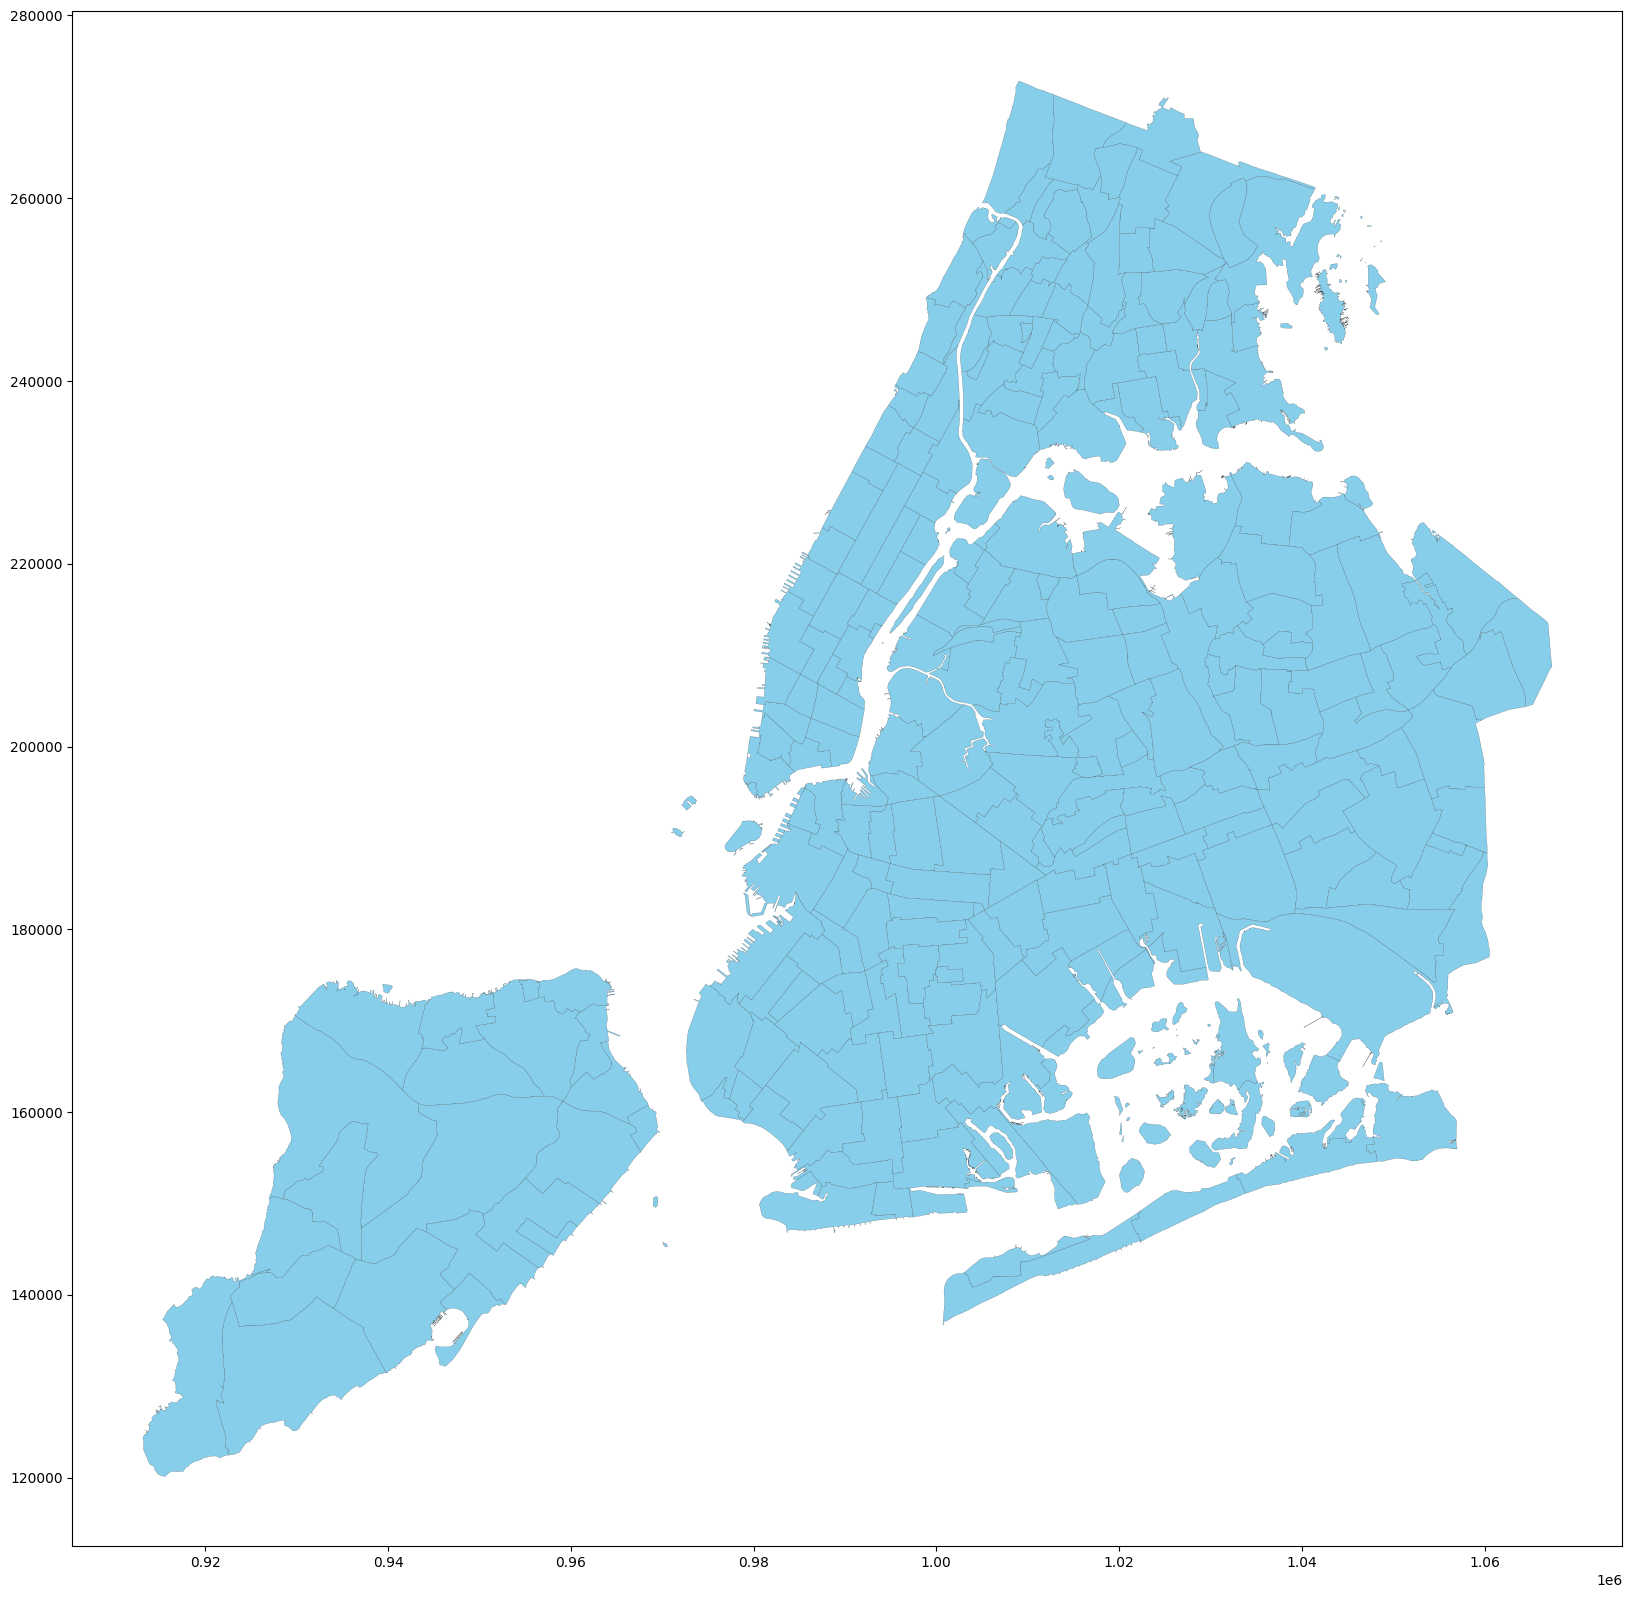

In [ ]:
nta_df.plot(
    figsize=(20,20),
    color = 'skyblue',
    edgecolor = 'black',
    linewidth=0.1,
    zorder=0,
    facecolor = 'lightgreen',
)

In [50]:
complaints_2025

,cmplnt_num,cmplnt_fr_dt,cmplnt_fr_tm,cmplnt_to_dt,cmplnt_to_tm,addr_pct_cd,rpt_dt,ky_cd,ofns_desc,pd_cd,...,susp_sex,transit_district,latitude,longitude,lat_lon,patrol_boro,station_name,vic_age_group,vic_race,vic_sex
0,318196597,2025-12-31T00:00:00.000,11:57:00,2025-12-31T00:00:00.000,12:05:00,40,2025-12-31T00:00:00.000,109,GRAND LARCENY,443.0,...,U,NaN,40.817356,-73.909331,"(40.817356, -73.909331)",PATROL BORO BRONX,(null),25-44,AMERICAN INDIAN/ALASKAN NATIVE,M
1,318202640,2025-12-31T00:00:00.000,17:10:00,2025-12-31T00:00:00.000,17:18:00,14,2025-12-31T00:00:00.000,118,DANGEROUS WEAPONS,793.0,...,F,NaN,40.754177,-73.984595,"(40.75417678, -73.98459514)",PATROL BORO MAN SOUTH,(null),UNKNOWN,UNKNOWN,E
2,318170925,2025-12-30T00:00:00.000,23:40:00,2025-12-31T00:00:00.000,00:27:00,101,2025-12-31T00:00:00.000,344,ASSAULT 3 & RELATED OFFENSES,113.0,...,M,NaN,40.599187,-73.750221,"(40.599187, -73.750221)",PATROL BORO QUEENS SOUTH,(null),18-24,BLACK,M
3,318205041,2025-12-23T00:00:00.000,17:56:00,2025-12-23T00:00:00.000,18:04:00,108,2025-12-31T00:00:00.000,341,PETIT LARCENY,321.0,...,M,NaN,40.746705,-73.943472,"(40.746705, -73.943472)",PATROL BORO QUEENS NORTH,(null),UNKNOWN,UNKNOWN,D
4,318204044,2025-12-31T00:00:00.000,19:39:00,2025-12-31T00:00:00.000,19:39:00,103,2025-12-31T00:00:00.000,351,CRIMINAL MISCHIEF & RELATED OF,258.0,...,(null),NaN,40.708380,-73.791676,"(40.70837971, -73.79167576)",PATROL BORO QUEENS SOUTH,(null),UNKNOWN,UNKNOWN,E
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
579556,298733274,2024-12-30T00:00:00.000,09:30:00,2024-12-31T00:00:00.000,14:30:00,48,2025-01-01T00:00:00.000,110,GRAND LARCENY OF MOTOR VEHICLE,441.0,...,(null),NaN,40.838593,-73.876457,"(40.838593, -73.876457)",PATROL BORO BRONX,(null),45-64,BLACK,F
579557,298749236,2025-01-01T00:00:00.000,00:50:00,2025-01-01T00:00:00.000,00:52:00,46,2025-01-01T00:00:00.000,113,FORGERY,725.0,...,M,NaN,40.847816,-73.907531,"(40.847815514765855, -73.90753109698773)",PATROL BORO BRONX,(null),UNKNOWN,UNKNOWN,M
579558,298712914,2025-01-01T00:00:00.000,03:10:00,2025-01-01T00:00:00.000,03:15:00,33,2025-01-01T00:00:00.000,110,GRAND LARCENY OF MOTOR VEHICLE,441.0,...,M,NaN,40.839531,-73.940889,"(40.839531, -73.940889)",PATROL BORO MAN NORTH,(null),45-64,AMERICAN INDIAN/ALASKAN NATIVE,M
579559,298712937,2025-01-01T00:00:00.000,01:22:00,2025-01-01T00:00:00.000,01:25:00,44,2025-01-01T00:00:00.000,118,DANGEROUS WEAPONS,792.0,...,M,NaN,40.844588,-73.904847,"(40.84458830022735, -73.90484654915383)",PATROL BORO BRONX,(null),UNKNOWN,UNKNOWN,E


In [49]:
complaints_2025.duplicated(subset='cmplnt_num').sum()

np.int64(0)

### 5. What years had more complaints happens

In [53]:
url = 'https://data.cityofnewyork.us/resource/qgea-i56i.json?$limit=50000'

In [54]:
complaints = pd.read_json(url)

In [55]:
complaints

,cmplnt_num,cmplnt_fr_dt,cmplnt_fr_tm,cmplnt_to_dt,cmplnt_to_tm,addr_pct_cd,rpt_dt,ky_cd,ofns_desc,pd_cd,...,station_name,vic_age_group,vic_race,vic_sex,:@computed_region_efsh_h5xi,:@computed_region_f5dn_yrer,:@computed_region_yeji_bk3q,:@computed_region_92fq_4b7q,:@computed_region_sbqj_enih,transit_district
0,318204068,2025-12-31T00:00:00.000,18:10:00,2025-12-31T00:00:00.000,18:12:00,120,2025-12-31T00:00:00.000,344,ASSAULT 3 & RELATED OFFENSES,101.0,...,(null),25-44,BLACK,F,10697.0,4.0,1.0,13.0,74.0,NaN
1,318243082,2025-12-30T00:00:00.000,13:00:00,2025-12-30T00:00:00.000,17:00:00,73,2025-12-31T00:00:00.000,341,PETIT LARCENY,352.0,...,(null),65+,BLACK,F,13516.0,55.0,2.0,17.0,46.0,NaN
2,318196673,2025-12-31T00:00:00.000,12:21:00,2025-12-31T00:00:00.000,12:21:00,103,2025-12-31T00:00:00.000,351,CRIMINAL MISCHIEF & RELATED OF,258.0,...,(null),UNKNOWN,UNKNOWN,E,24672.0,41.0,3.0,6.0,61.0,NaN
3,318172880,2025-12-31T00:00:00.000,02:22:00,2025-12-31T00:00:00.000,02:30:00,25,2025-12-31T00:00:00.000,344,ASSAULT 3 & RELATED OFFENSES,101.0,...,(null),45-64,BLACK,M,13093.0,7.0,4.0,35.0,16.0,NaN
4,318196708,2025-12-29T00:00:00.000,17:00:00,2025-12-29T00:00:00.000,17:13:00,122,2025-12-31T00:00:00.000,348,VEHICLE AND TRAFFIC LAWS,916.0,...,(null),45-64,BLACK,F,10692.0,30.0,1.0,14.0,76.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,316703271,2025-11-26T00:00:00.000,22:15:00,2025-11-26T00:00:00.000,22:35:00,63,2025-11-26T00:00:00.000,106,FELONY ASSAULT,109.0,...,(null),25-44,ASIAN / PACIFIC ISLANDER,M,13825.0,5.0,2.0,26.0,38.0,NaN
49996,316694458,2025-11-26T00:00:00.000,18:53:00,2025-11-26T00:00:00.000,18:56:00,14,2025-11-26T00:00:00.000,109,GRAND LARCENY,405.0,...,(null),45-64,ASIAN / PACIFIC ISLANDER,M,12080.0,11.0,4.0,10.0,8.0,NaN
49997,316660030,2025-11-25T00:00:00.000,22:00:00,2025-11-25T00:00:00.000,22:30:00,103,2025-11-26T00:00:00.000,341,PETIT LARCENY,321.0,...,(null),25-44,ASIAN / PACIFIC ISLANDER,M,24340.0,41.0,3.0,6.0,61.0,NaN
49998,316772680,2025-11-21T00:00:00.000,22:00:00,2025-11-21T00:00:00.000,23:00:00,30,2025-11-26T00:00:00.000,344,ASSAULT 3 & RELATED OFFENSES,101.0,...,(null),18-24,BLACK HISPANIC,M,12428.0,37.0,4.0,23.0,19.0,NaN
